# Object Detection for Self-Driving Cars

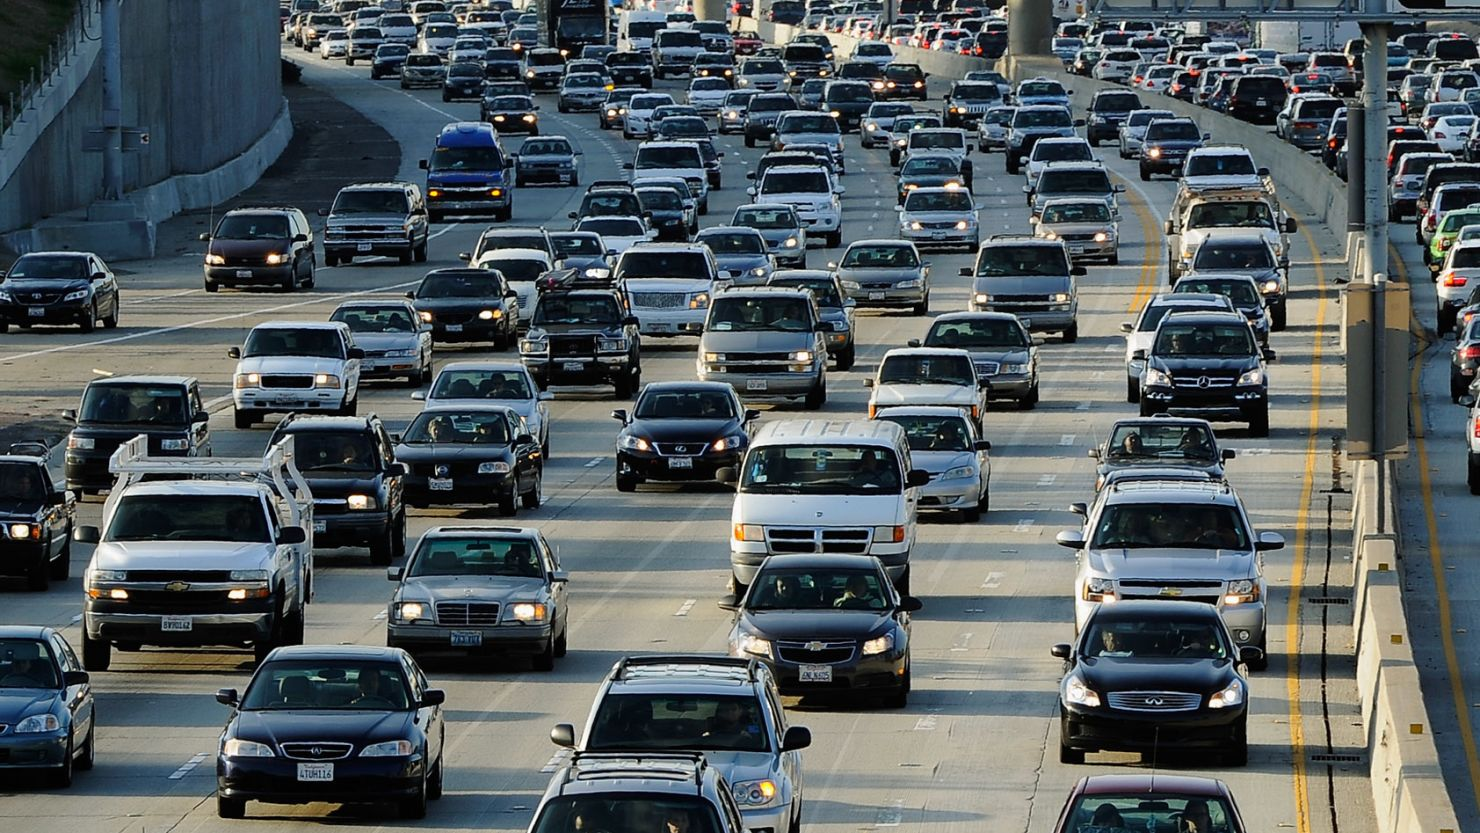

<a class="anchor" id="About_Data"></a>
# <p style="padding:10px;background-color:#d5eae9;margin:0;color:#c27849;font-family:newtimeroman;font-size:150%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">About Data</p> 

<div style="background-color:#d5eae9; padding:20px; font-size:15px">

**Dataset:** 

The dataset consists of image frames extracted from car camera(s) installed in various positions. The frames are meant for object detection tasks, especially in contexts like road scenes, identifying other vehicles, pedestrians, or relevant objects from a moving vehicle’s perspective.


**Objective:**   

The aim of this project is to build and train models that are capable of real-time object detection on images captured by car-mounted cameras. Specifically, we train and compare two widely used architectures: YOLO (You Only Look Once) and SSD (Single Shot MultiBox Detector).


**Licence:**

This notebook is licensed under a [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International License](https://creativecommons.org/licenses/by-nc-sa/4.0/).


Shape of dataset: (132406, 6)

First rows:
                      frame  xmin  xmax  ymin  ymax  class_id
0  1478019952686311006.jpg   237   251   143   155         1
1  1478019952686311006.jpg   437   454   120   186         3
2  1478019953180167674.jpg   218   231   146   158         1
3  1478019953689774621.jpg   171   182   141   154         2
4  1478019953689774621.jpg   179   191   144   155         1

Class distribution:
class_id
1    101314
5     12700
3     10637
2      6313
4      1442
Name: count, dtype: int64


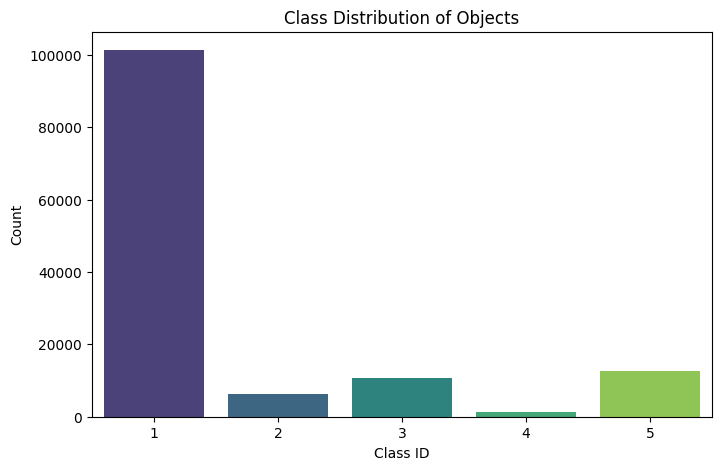

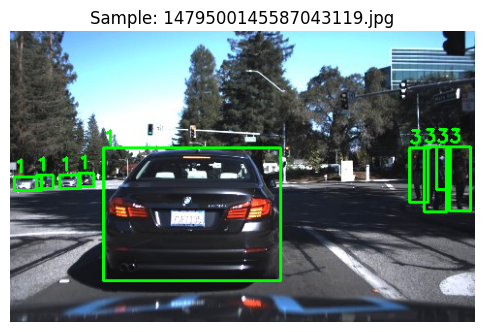

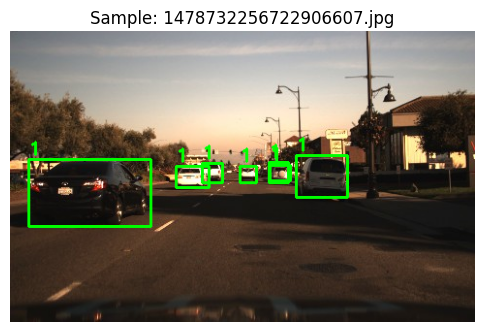

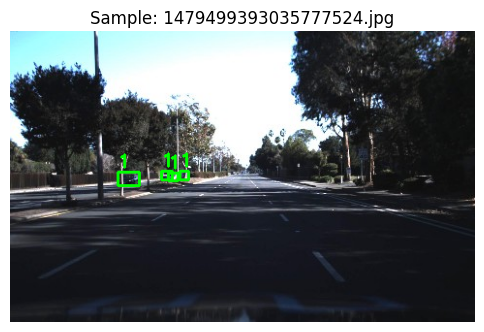

In [1]:
# Exploring the Dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
from pathlib import Path

# Load CSV annotations
csv_path = "/kaggle/input/car-camera-photos/labels_train.csv"
df = pd.read_csv(csv_path)

print("Shape of dataset:", df.shape)
print("\nFirst rows:\n", df.head())
print("\nClass distribution:")
print(df['class_id'].value_counts())

# Class distribution plot
plt.figure(figsize=(8,5))
sns.countplot(x='class_id', data=df, palette='viridis')
plt.title("Class Distribution of Objects")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.show()

# Show some sample images with bounding boxes
IMG_DIR = Path("/kaggle/input/car-camera-photos/images/images")

def plot_samples(n=3):
    samples = df.sample(n)['frame'].values
    for img_name in samples:
        img_path = IMG_DIR / img_name
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        # Draw bounding boxes
        annots = df[df['frame']==img_name]
        for _, row in annots.iterrows():
            cv2.rectangle(img, (int(row['xmin']), int(row['ymin'])), 
                               (int(row['xmax']), int(row['ymax'])), 
                               (0,255,0), 2)
            cv2.putText(img, str(row['class_id']), 
                        (int(row['xmin']), int(row['ymin'])-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)
        plt.figure(figsize=(6,6))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.title(f"Sample: {img_name}")
        plt.show()

plot_samples(3)


<a class="anchor" id="About_Data"></a>
# <p style="padding:10px;background-color:#d5eae9;margin:0;color:#c27849;font-family:newtimeroman;font-size:150%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Model 1: YOLO</p> 

In [2]:
import os
os.environ["OPENCV_LOG_LEVEL"] = "SILENT"

In [3]:
import cv2
import warnings
warnings.filterwarnings("ignore")

In [4]:
# Install required packages
!pip install -q ultralytics pycocotools torchmetrics albumentations tqdm

# Python imports
import os
import json
import shutil
from pathlib import Path
from tqdm import tqdm

import numpy as np
import pandas as pd
import cv2
from sklearn.model_selection import train_test_split

import torch
print("Torch:", torch.__version__, "CUDA available:", torch.cuda.is_available(), "CUDA:", torch.version.cuda)


Torch: 2.1.2 CUDA available: True CUDA: 12.1


In [5]:
# Paths & seed 
ROOT = Path("/kaggle/input/car-camera-photos")
IMAGES_DIR = ROOT / "images"
CSV_PATH = ROOT / "labels_train.csv"

WORK_DIR = Path("/kaggle/working")
DATA_DIR = WORK_DIR / "datasets"
YOLO_DIR = DATA_DIR / "yolo"
COCO_DIR = DATA_DIR / "coco"

os.makedirs(YOLO_DIR, exist_ok=True)
os.makedirs(COCO_DIR, exist_ok=True)

# Set reproducible seed
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("CSV exists:", CSV_PATH.exists())
print("Some example images exist:", (IMAGES_DIR).exists())


CSV exists: True
Some example images exist: True


In [6]:
# Load CSV
df = pd.read_csv(CSV_PATH)

print("CSV columns:", df.columns.tolist())

# Ensure filenames 
df['frame'] = df['frame'].astype(str).str.strip()
df['frame'] = df['frame'].apply(lambda x: x if x.endswith(".jpg") else x + ".jpg")

# Train/val split 
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

print("Train samples:", len(train_df))
print("Val samples:", len(val_df))


CSV columns: ['frame', 'xmin', 'xmax', 'ymin', 'ymax', 'class_id']
Train samples: 105924
Val samples: 26482


In [7]:
# Correct images directory
IMAGES_DIR = Path("/kaggle/input/car-camera-photos/images/images")

CSV_PATH = Path("/kaggle/input/car-camera-photos/labels_train.csv")

In [8]:
from tqdm import tqdm
from collections import defaultdict

splits = {'train': train_df, 'val': val_df}

for split, split_df in splits.items():
    img_out = YOLO_DIR / split / "images"
    lbl_out = YOLO_DIR / split / "labels"
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    # Cache image sizes 
    size_cache = {}
    print(f"\n[{split.upper()}] Caching image sizes...")
    for img_name in tqdm(split_df['frame'].unique(), desc=f"{split} images"):
        img_file = IMAGES_DIR / img_name
        if not img_file.exists():
            continue
        img = cv2.imread(str(img_file))
        if img is None:
            continue
        h_img, w_img = img.shape[:2]
        size_cache[img_name] = (h_img, w_img)
        shutil.copy(img_file, img_out / img_file.name)

    # Write labels 
    print(f"[{split.upper()}] Writing YOLO labels...")
    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"{split} labels"):
        img_name = row['frame']
        if img_name not in size_cache:
            continue
        h_img, w_img = size_cache[img_name]

        cls = int(row['class_id']) - 1
        x_center = (row['xmin'] + row['xmax']) / 2 / w_img
        y_center = (row['ymin'] + row['ymax']) / 2 / h_img
        w = (row['xmax'] - row['xmin']) / w_img
        h = (row['ymax'] - row['ymin']) / h_img

        with open(lbl_out / f"{Path(img_name).stem}.txt", "a") as f:
            f.write(f"{cls} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}\n")

print("\nOptimized YOLO dataset prepared successfully")



[TRAIN] Caching image sizes...


train images: 100%|██████████| 17707/17707 [02:12<00:00, 134.05it/s]


[TRAIN] Writing YOLO labels...


train labels: 100%|██████████| 105924/105924 [00:16<00:00, 6517.56it/s]



[VAL] Caching image sizes...


val images: 100%|██████████| 12950/12950 [00:42<00:00, 306.19it/s]


[VAL] Writing YOLO labels...


val labels: 100%|██████████| 26482/26482 [00:04<00:00, 5989.79it/s]


Optimized YOLO dataset prepared successfully


In [9]:
# Count images and labels
train_imgs = list((YOLO_DIR / "train" / "images").glob("*.jpg"))
val_imgs   = list((YOLO_DIR / "val" / "images").glob("*.jpg"))
train_lbls = list((YOLO_DIR / "train" / "labels").glob("*.txt"))
val_lbls   = list((YOLO_DIR / "val" / "labels").glob("*.txt"))

print("YOLO train images:", len(train_imgs))
print("YOLO val images:", len(val_imgs))
print("YOLO train labels:", len(train_lbls))
print("YOLO val labels:", len(val_lbls))

YOLO train images: 17707
YOLO val images: 12950
YOLO train labels: 17707
YOLO val labels: 12950


In [10]:
import yaml

class_names = sorted(df['class_id'].unique().tolist())
names = [f"class_{c}" for c in class_names]

data_yaml = {
    'train': str(YOLO_DIR / "train" / "images"),
    'val':   str(YOLO_DIR / "val" / "images"),
    'nc':    len(class_names),
    'names': names
}

with open(DATA_DIR / "data.yaml", "w") as f:
    yaml.dump(data_yaml, f)

print("data.yaml saved at:", DATA_DIR / "data.yaml")


data.yaml saved at: /kaggle/working/datasets/data.yaml


In [11]:
from ultralytics import YOLO

# Load pretrained YOLOv8 
model = YOLO("yolov8n.pt")  

# Train
model.train(
    data=str(DATA_DIR / "data.yaml"),
    epochs=50,
    imgsz=640,
    batch=32,
    device=0  # use GPU P100
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.240 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/datasets/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7

2025-12-21 13:04:30,768	INFO util.py:124 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-12-21 13:04:31,464	INFO util.py:124 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Overriding model.yaml nc=80 with nc=5

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b825c166aa0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [12]:
# Saving the model

#from ultralytics import YOLO
#import os

SAVE_DIR = "/kaggle/working/saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

YOLO_SAVE_PATH = f"{SAVE_DIR}/yolo_final.pt"

model.save(YOLO_SAVE_PATH)

print(f"YOLO model saved at: {YOLO_SAVE_PATH}")


YOLO model saved at: /kaggle/working/saved_models/yolo_final.pt


In [14]:
import shutil
# Copy the best weights to output directory
shutil.copy(
    "/kaggle/working/runs/detect/train/weights/best.pt",
    "/kaggle/working/best_yolo.pt"  # or /kaggle/working/output/best_yolo.pt
)


'/kaggle/working/best_yolo.pt'

In [17]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
import pandas as pd

# Load the trained YOLO model
model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

# Run evaluation 
metrics = model.val(data=str(DATA_DIR / "data.yaml"))  
save_dir = Path(metrics.save_dir)
print("YOLO validation results saved in:", save_dir)

# Extract metrics 
precision = metrics.box.p.mean()
recall = metrics.box.r.mean()
map50 = metrics.box.map50.mean()
map5095 = metrics.box.map.mean()

# Put into a DataFrame
df = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'mAP50', 'mAP50-95'],
    'Value': [precision, recall, map50, map5095]
})
print(df)

# Per-class metrics 
for i, c in enumerate(metrics.ap_class_index):
    p, r, map50, map5095 = metrics.class_result(i)
    print(f"Class {c} -> Precision: {p:.3f}, Recall: {r:.3f}, "
          f"mAP50: {map50:.3f}, mAP50-95: {map5095:.3f}")

# Show confusion matrix 
metrics.confusion_matrix.plot()  

# Display plots inline 
plots_dir = Path(model.ckpt_path).parent  
print("Plots directory:", plots_dir)

# List of YOLO-generated images
images_to_show = [
    plots_dir / "PR_curve.png",
    plots_dir / "F1_curve.png",
    plots_dir / "confusion_matrix.png",
    plots_dir / "results.png"
]

for img_path in images_to_show:
    if img_path.exists():
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8,6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(img_path.name)
        plt.show()


Ultralytics 8.3.240 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 935.0±198.1 MB/s, size: 42.8 KB)
val: Scanning /kaggle/working/datasets/yolo/val/labels.cache... 12950 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 12950/12950 15.0Mit/s 0.0s
val: /kaggle/working/datasets/yolo/val/images/1478732688555973177.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 810/810 12.1it/s 1:07<0.1ss
                   all      12950      26481       0.23      0.625      0.197      0.108
               class_1      11376      20260      0.237      0.783      0.229      0.146
               class_2       1172       1265      0.216      0.635      0.196       0.13
               class_3       1559       2084      0.213      0.449      0.157     0.0705
         

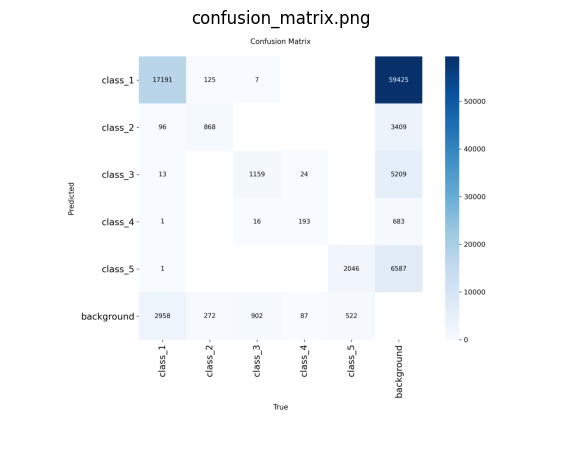

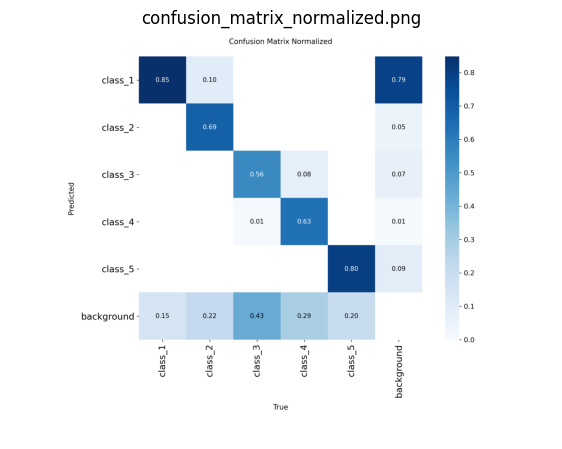

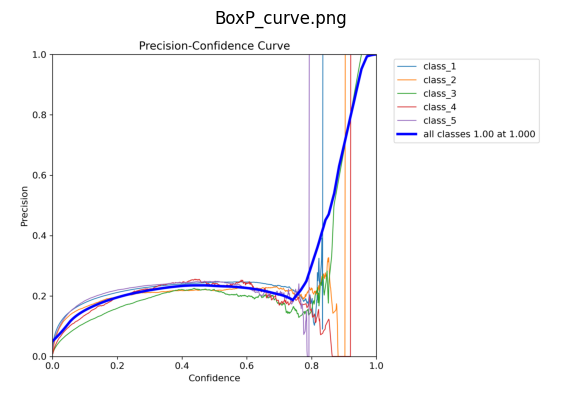

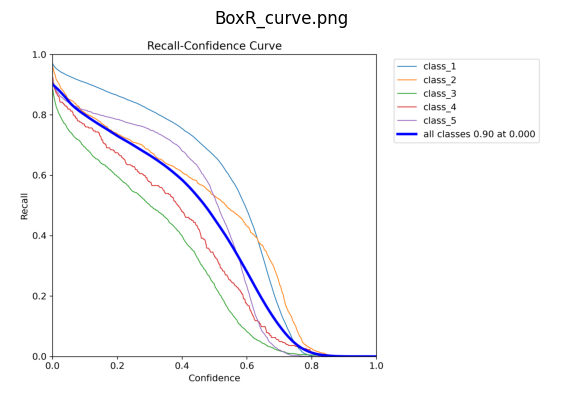

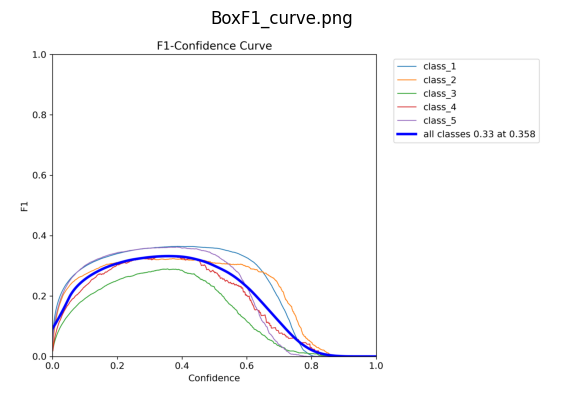

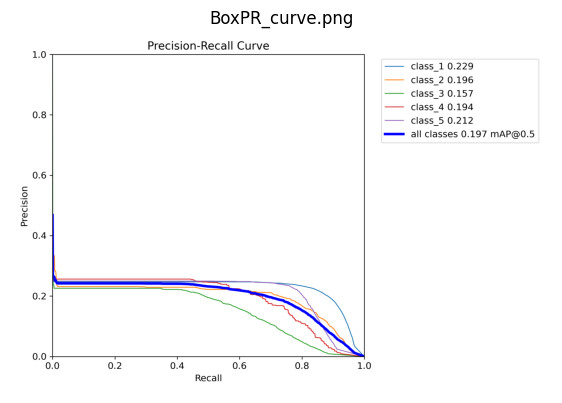

In [18]:
from pathlib import Path
import matplotlib.pyplot as plt
import cv2

plots_dir = Path(metrics.save_dir)

plot_files = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
    "BoxF1_curve.png",
    "BoxPR_curve.png"
]

for file in plot_files:
    img_path = plots_dir / file
    if img_path.exists():
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(7,7))
        plt.imshow(img)
        plt.axis("off")
        plt.title(file)
        plt.show()
    else:
        print(f"{file} not found in {plots_dir}")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /kaggle/working/runs/detect/predict


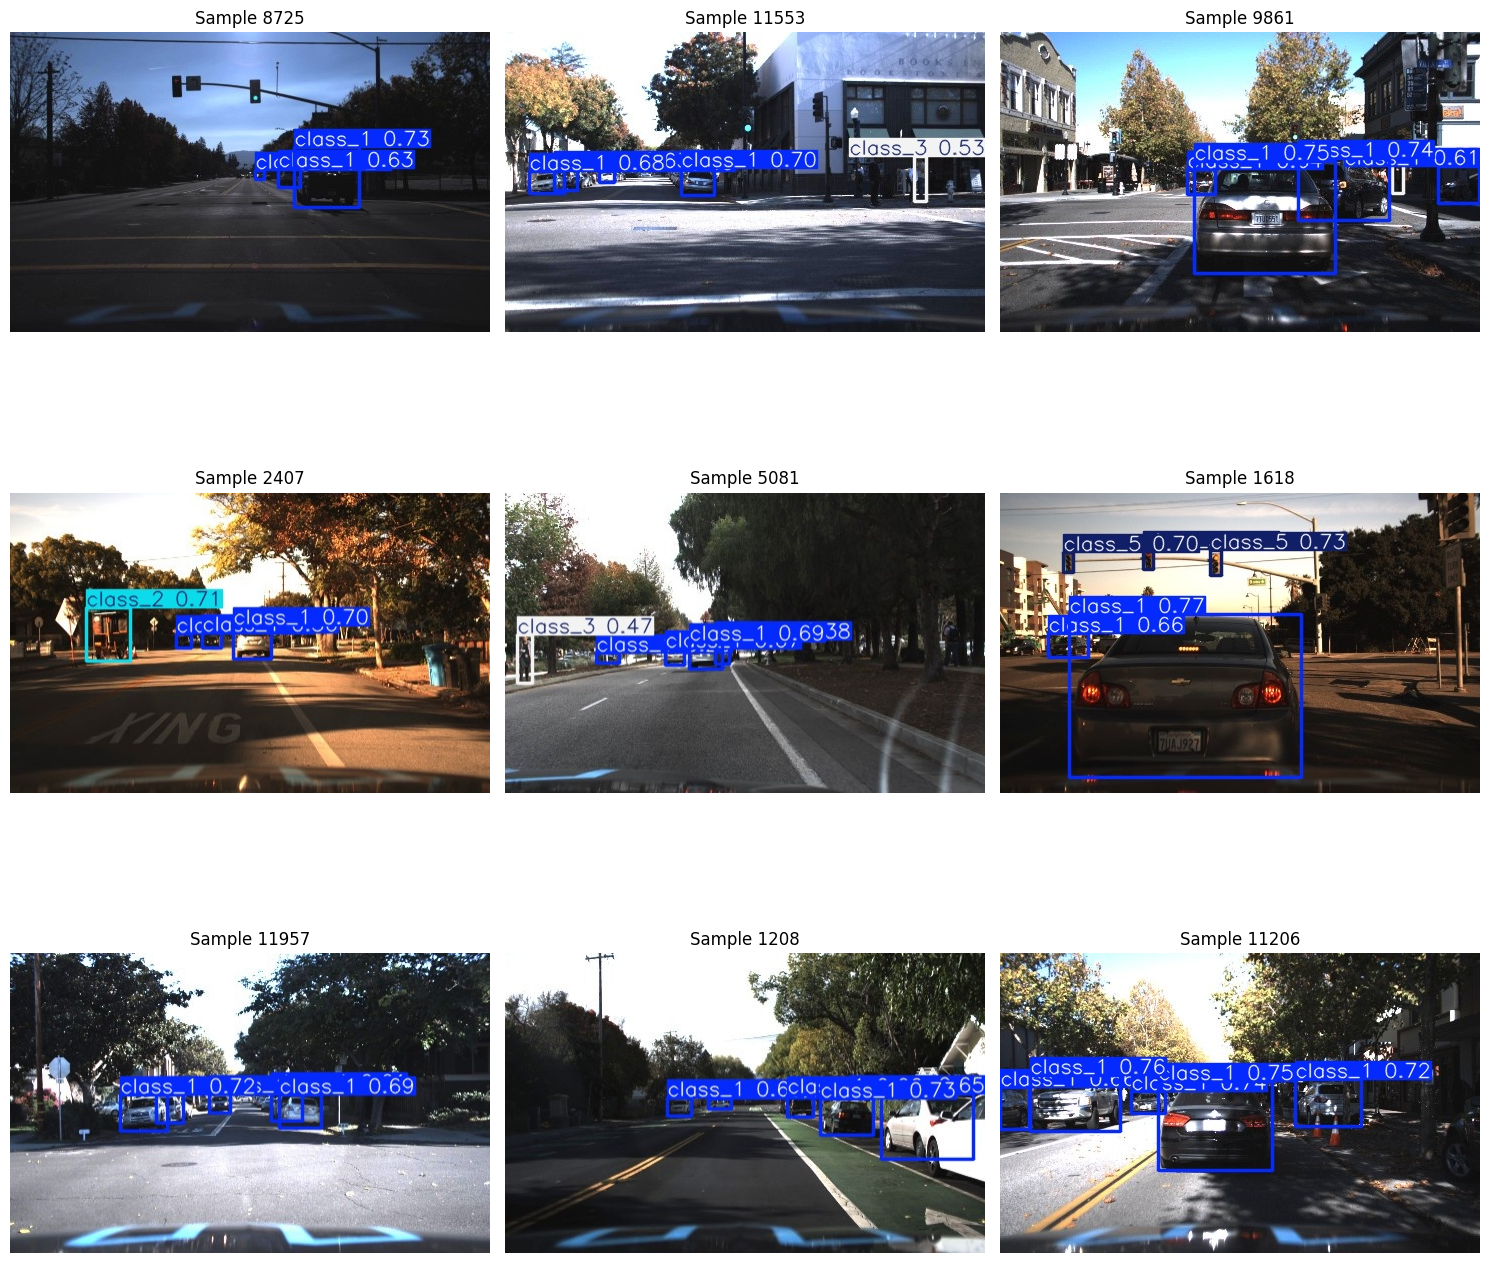

In [19]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
import random

# Load trained model
model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

# Run prediction on validation images
results = model.predict(
    source="/kaggle/working/datasets/yolo/val/images",
    save=True,
    conf=0.25,
    imgsz=640,
    verbose=False,
    max_det=5,
    save_txt=False
)

# Pick 9 random results
n_show = min(9, len(results))
sample_indices = random.sample(range(len(results)), n_show)

# Plot in grid
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for i, ax in enumerate(axes.flat):
    if i < n_show:
        idx = sample_indices[i]
        pred_img_path = Path(results[idx].save_dir) / Path(results[idx].path).name
        img = cv2.imread(str(pred_img_path))
        if img is not None:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            ax.axis("off")
            ax.set_title(f"Sample {idx}")
        else:
            ax.axis("off")
            ax.set_title("Image not found")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()


<a class="anchor" id="About_Data"></a>
# <p style="padding:10px;background-color:#d5eae9;margin:0;color:#c27849;font-family:newtimeroman;font-size:150%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Model 2: SSD</p> 

In [11]:
import torch
from torch.utils.data import Dataset
from pathlib import Path
import cv2
import torchvision.transforms as T

class YOLO2SSD_Dataset(Dataset):
    def __init__(self, img_dir, label_dir, img_size=300):
        self.img_dir = Path(img_dir)
        self.label_dir = Path(label_dir)
        self.imgs = sorted(self.img_dir.glob("*.jpg"))
        self.img_size = img_size

        self.transform = T.Compose([
            T.ToTensor(),
            T.Resize((img_size, img_size))
        ])

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_path = self.imgs[idx]
        label_path = self.label_dir / (img_path.stem + ".txt")

        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        boxes = []
        labels = []

        if label_path.exists():
            with open(label_path) as f:
                for line in f:
                    cls, x, y, bw, bh = map(float, line.split())

                    xmin = (x - bw / 2) * w
                    ymin = (y - bh / 2) * h
                    xmax = (x + bw / 2) * w
                    ymax = (y + bh / 2) * h

                    if xmax > xmin and ymax > ymin:
                        boxes.append([xmin, ymin, xmax, ymax])
                        labels.append(int(cls) + 1)  # background = 0

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        img = self.transform(img)

        # Scale boxes AFTER resize
        scale_x = self.img_size / w
        scale_y = self.img_size / h
        if boxes.numel() > 0:
            boxes[:, [0, 2]] *= scale_x
            boxes[:, [1, 3]] *= scale_y

            boxes[:, 0::2].clamp_(0, self.img_size)
            boxes[:, 1::2].clamp_(0, self.img_size)

            valid = (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1])
            boxes = boxes[valid]
            labels = labels[valid]

        target = {"boxes": boxes, "labels": labels}
        return img, target


In [12]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    imgs, targets = zip(*batch)
    return list(imgs), list(targets)

train_dataset = YOLO2SSD_Dataset(
    img_dir="/kaggle/working/datasets/yolo/train/images",
    label_dir="/kaggle/working/datasets/yolo/train/labels"
)

val_dataset = YOLO2SSD_Dataset(
    img_dir="/kaggle/working/datasets/yolo/val/images",
    label_dir="/kaggle/working/datasets/yolo/val/labels"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=collate_fn
)

print("Train:", len(train_dataset), "Val:", len(val_dataset))


Train: 17707 Val: 12950


In [13]:
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.models.detection import ssd300_vgg16
from torchvision.ops import nms
import os


# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# SSD MODEL
NUM_CLASSES = len(class_names) + 1  # +1 background (SSD requirement)

ssd_model = ssd300_vgg16(
    weights=None,
    num_classes=NUM_CLASSES
)
ssd_model.to(device)

print("SSD model created")
print("Trainable parameters:",
      sum(p.numel() for p in ssd_model.parameters() if p.requires_grad))

# Training Setup
num_epochs = 50  
checkpoint_path = "/kaggle/working/ssd_checkpoint.pth"
final_model_path = "/kaggle/working/best_ssd.pth"

CONF_THRESH = 0.25
NMS_IOU_THRESH = 0.5

params = [p for p in ssd_model.parameters() if p.requires_grad]
assert len(params) > 0, "SSD has no trainable parameters!"

optimizer = optim.SGD(
    params,
    lr=5e-4,             
    momentum=0.9,
    weight_decay=5e-4
)
scheduler = StepLR(optimizer, step_size=20, gamma=0.1)

# Resume from checkpoint
start_epoch = 0
best_map = 0.0

if os.path.exists(checkpoint_path):
    print("Resuming from checkpoint:", checkpoint_path)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    ssd_model.load_state_dict(checkpoint["model"])
    optimizer.load_state_dict(checkpoint["optimizer"])
    scheduler.load_state_dict(checkpoint["scheduler"])
    start_epoch = checkpoint["epoch"] + 1
    best_map = checkpoint.get("best_map", 0.0)

# Training & Validation Loop
for epoch in range(start_epoch, num_epochs):

    # Training
    ssd_model.train()
    running_loss = 0.0
    num_batches = 0

    for imgs, targets in train_loader:

        # Skip images with no boxes
        valid_idx = [i for i, t in enumerate(targets) if t["boxes"].numel() > 0]
        if len(valid_idx) == 0:
            continue

        imgs = [imgs[i].to(device) for i in valid_idx]
        targets = [
            {k: v.to(device) for k, v in targets[i].items()}
            for i in valid_idx
        ]

        loss_dict = ssd_model(imgs, targets)
        loss = sum(loss_dict.values())

        # Hard NaN protection
        if not torch.isfinite(loss):
            print("NaN or Inf loss detected — skipping batch")
            optimizer.zero_grad()
            continue

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        num_batches += 1

    scheduler.step()
    avg_loss = running_loss / max(1, num_batches)

    print(f"Epoch [{epoch+1}/{num_epochs}] Training Loss: {avg_loss:.4f}")

   
    # Validation 
    ssd_model.eval()
    metric = MeanAveragePrecision(iou_type="bbox")

    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs = [img.to(device) for img in imgs]
            targets = [
                {k: v.to(device) for k, v in t.items()}
                for t in targets
            ]

            raw_preds = ssd_model(imgs)
            filtered_preds = []

            for pred in raw_preds:
                boxes = pred["boxes"]
                scores = pred["scores"]
                labels = pred["labels"]

                keep = scores >= CONF_THRESH
                boxes = boxes[keep]
                scores = scores[keep]
                labels = labels[keep]

                if boxes.numel() > 0:
                    keep_idx = nms(boxes, scores, NMS_IOU_THRESH)
                    boxes = boxes[keep_idx]
                    scores = scores[keep_idx]
                    labels = labels[keep_idx]

                filtered_preds.append({
                    "boxes": boxes,
                    "scores": scores,
                    "labels": labels
                })

            metric.update(filtered_preds, targets)

    val_metrics = metric.compute()
    map50 = val_metrics["map_50"].item()
    map5095 = val_metrics["map"].item()

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Validation mAP50: {map50:.4f}, "
        f"mAP50-95: {map5095:.4f}"
    )

    # Checkpointing
    torch.save({
        "epoch": epoch,
        "model": ssd_model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "best_map": best_map
    }, checkpoint_path)

    if map50 > best_map:
        best_map = map50
        torch.save(ssd_model.state_dict(), final_model_path)
        print("Best SSD model saved")

# Final Save
torch.save(ssd_model.state_dict(), final_model_path)
print(f"Final SSD model saved at: {final_model_path}")


Using device: cuda


Downloading: "https://download.pytorch.org/models/vgg16_features-amdegroot-88682ab5.pth" to /root/.cache/torch/hub/checkpoints/vgg16_features-amdegroot-88682ab5.pth
100%|██████████| 528M/528M [00:02<00:00, 193MB/s] 


SSD model created
Trainable parameters: 24241836
Epoch [1/50] Training Loss: 12.5208
Epoch [1/50] Validation mAP50: 0.0050, mAP50-95: 0.0017
Best SSD model saved
Epoch [2/50] Training Loss: 5.0316
Epoch [2/50] Validation mAP50: 0.0332, mAP50-95: 0.0130
Best SSD model saved
Epoch [3/50] Training Loss: 4.3591
Epoch [3/50] Validation mAP50: 0.0412, mAP50-95: 0.0184
Best SSD model saved
Epoch [4/50] Training Loss: 4.1290
Epoch [4/50] Validation mAP50: 0.0521, mAP50-95: 0.0229
Best SSD model saved
Epoch [5/50] Training Loss: 3.9854
Epoch [5/50] Validation mAP50: 0.0642, mAP50-95: 0.0284
Best SSD model saved
Epoch [6/50] Training Loss: 3.8741
Epoch [6/50] Validation mAP50: 0.0700, mAP50-95: 0.0325
Best SSD model saved
Epoch [7/50] Training Loss: 3.7774
Epoch [7/50] Validation mAP50: 0.0684, mAP50-95: 0.0284
Epoch [8/50] Training Loss: 3.6996
Epoch [8/50] Validation mAP50: 0.0809, mAP50-95: 0.0342
Best SSD model saved
Epoch [9/50] Training Loss: 3.6109
Epoch [9/50] Validation mAP50: 0.0727, m

In [29]:
import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.ops import nms
import pandas as pd

# Config
CONF_THRESH = 0.25
NMS_IOU_THRESH = 0.5

ssd_model.eval()
metric = MeanAveragePrecision(iou_type="bbox")

with torch.no_grad():
    for imgs, targets in val_loader:
        imgs = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        preds = ssd_model(imgs)
        filtered_preds = []

        for p in preds:
            boxes = p["boxes"]
            scores = p["scores"]
            labels = p["labels"]

            keep = scores >= CONF_THRESH
            boxes, scores, labels = boxes[keep], scores[keep], labels[keep]

            if boxes.numel() > 0:
                keep_idx = nms(boxes, scores, NMS_IOU_THRESH)
                boxes, scores, labels = boxes[keep_idx], scores[keep_idx], labels[keep_idx]

            filtered_preds.append({
                "boxes": boxes,
                "scores": scores,
                "labels": labels
            })

        metric.update(filtered_preds, targets)

# Results
results = metric.compute()

precision = results["map"].item()        # proxy 
recall = results["mar_100"].item()
map50 = results["map_50"].item()
map5095 = results["map"].item()

df = pd.DataFrame({
    "Metric": ["Recall@100", "mAP50", "mAP50-95"],
    "Value": [recall, map50, map5095]
})

print(df)


       Metric     Value
0  Recall@100  0.140668
1       mAP50  0.033053
2    mAP50-95  0.013192


In [33]:
from collections import Counter

gt_counter = Counter()

for _, targets in val_loader:
    for t in targets:
        gt_counter.update(t["labels"].tolist())

print("GT boxes per class:")
for k, v in sorted(gt_counter.items()):
    print(f"Class {k}: {v}")


GT boxes per class:
Class 1: 20259
Class 2: 1265
Class 3: 2084
Class 4: 304
Class 5: 2569


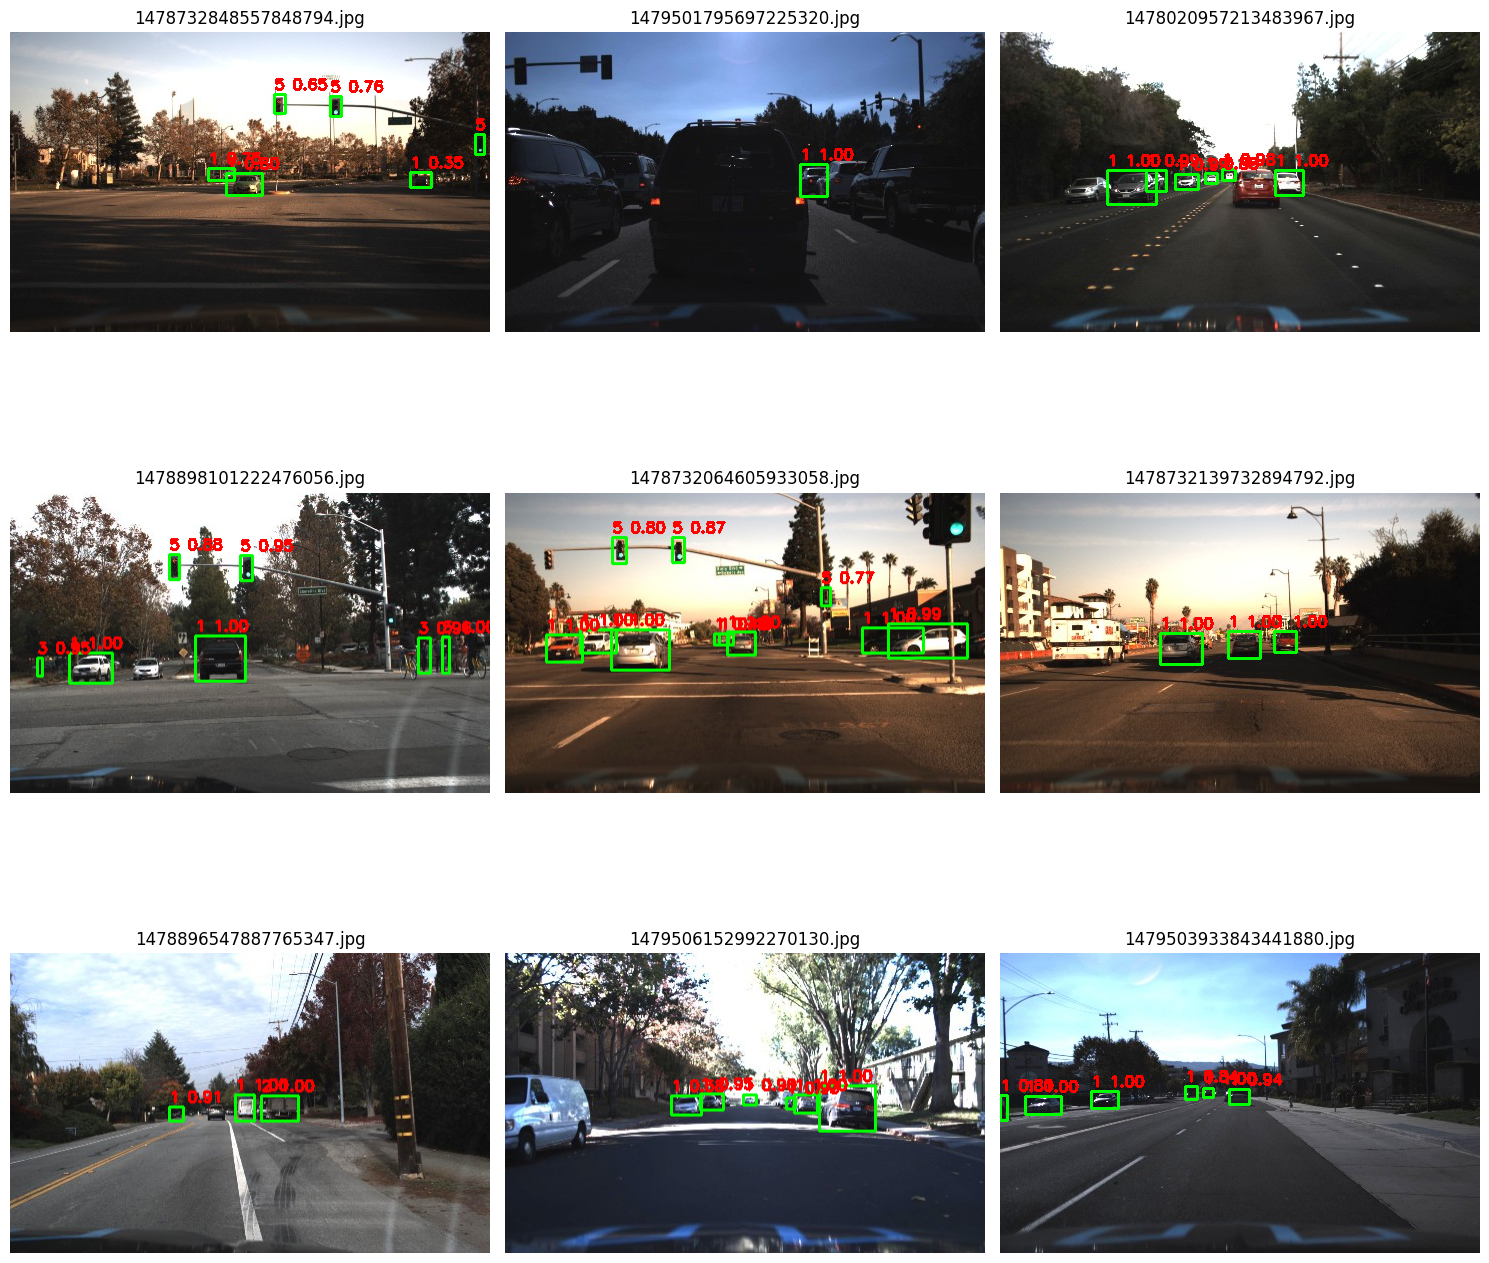

In [28]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import random

# Prediction directory
SAVE_DIR = Path("/kaggle/working/ssd_predictions")
SAVE_DIR.mkdir(exist_ok=True)

ssd_model.eval()

img_paths = list(Path("/kaggle/working/datasets/yolo/val/images").glob("*.jpg"))
sample_imgs = random.sample(img_paths, min(9, len(img_paths)))

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

with torch.no_grad():
    for ax, img_path in zip(axes.flat, sample_imgs):

        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img_tensor = torch.from_numpy(img_rgb).permute(2, 0, 1).float() / 255.0
        img_tensor = img_tensor.to(device)

        pred = ssd_model([img_tensor])[0]

        boxes = pred["boxes"]
        scores = pred["scores"]
        labels = pred["labels"]

        keep = scores >= CONF_THRESH
        boxes, scores, labels = boxes[keep], scores[keep], labels[keep]

        if boxes.numel() > 0:
            keep_idx = nms(boxes, scores, NMS_IOU_THRESH)
            boxes, scores, labels = boxes[keep_idx], scores[keep_idx], labels[keep_idx]

        # Draw boxes
        for box, score, label in zip(boxes, scores, labels):
            x1, y1, x2, y2 = map(int, box.tolist())
            cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(
                img_rgb,
                f"{class_names[label-1]} {score:.2f}",
                (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255, 0, 0),
                2
            )

        ax.imshow(img_rgb)
        ax.axis("off")
        ax.set_title(img_path.name)

plt.tight_layout()
plt.show()


<div style="background-color:#d5eae9; padding:20px; font-size:15px">

**Tanks for the time you took to observe this notebook** 


**Author: Mohammad Bagher Soroush**